Nome: Natália da Silva Guimarães

RA: 298997

Curso: Engenharia Elétrica (Mestrado)



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais:
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação.

In [35]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook.

In [36]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [37]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

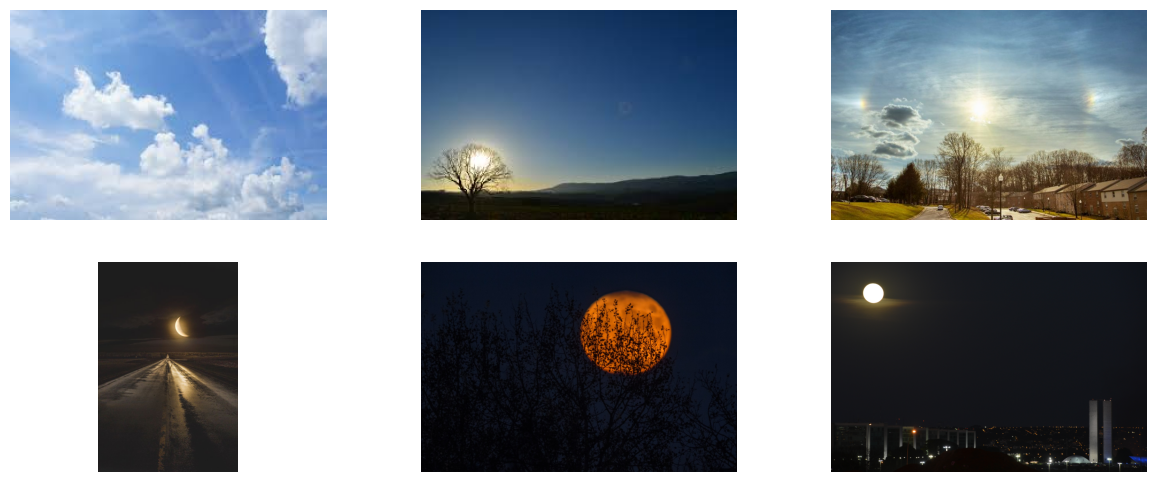

In [38]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:

  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

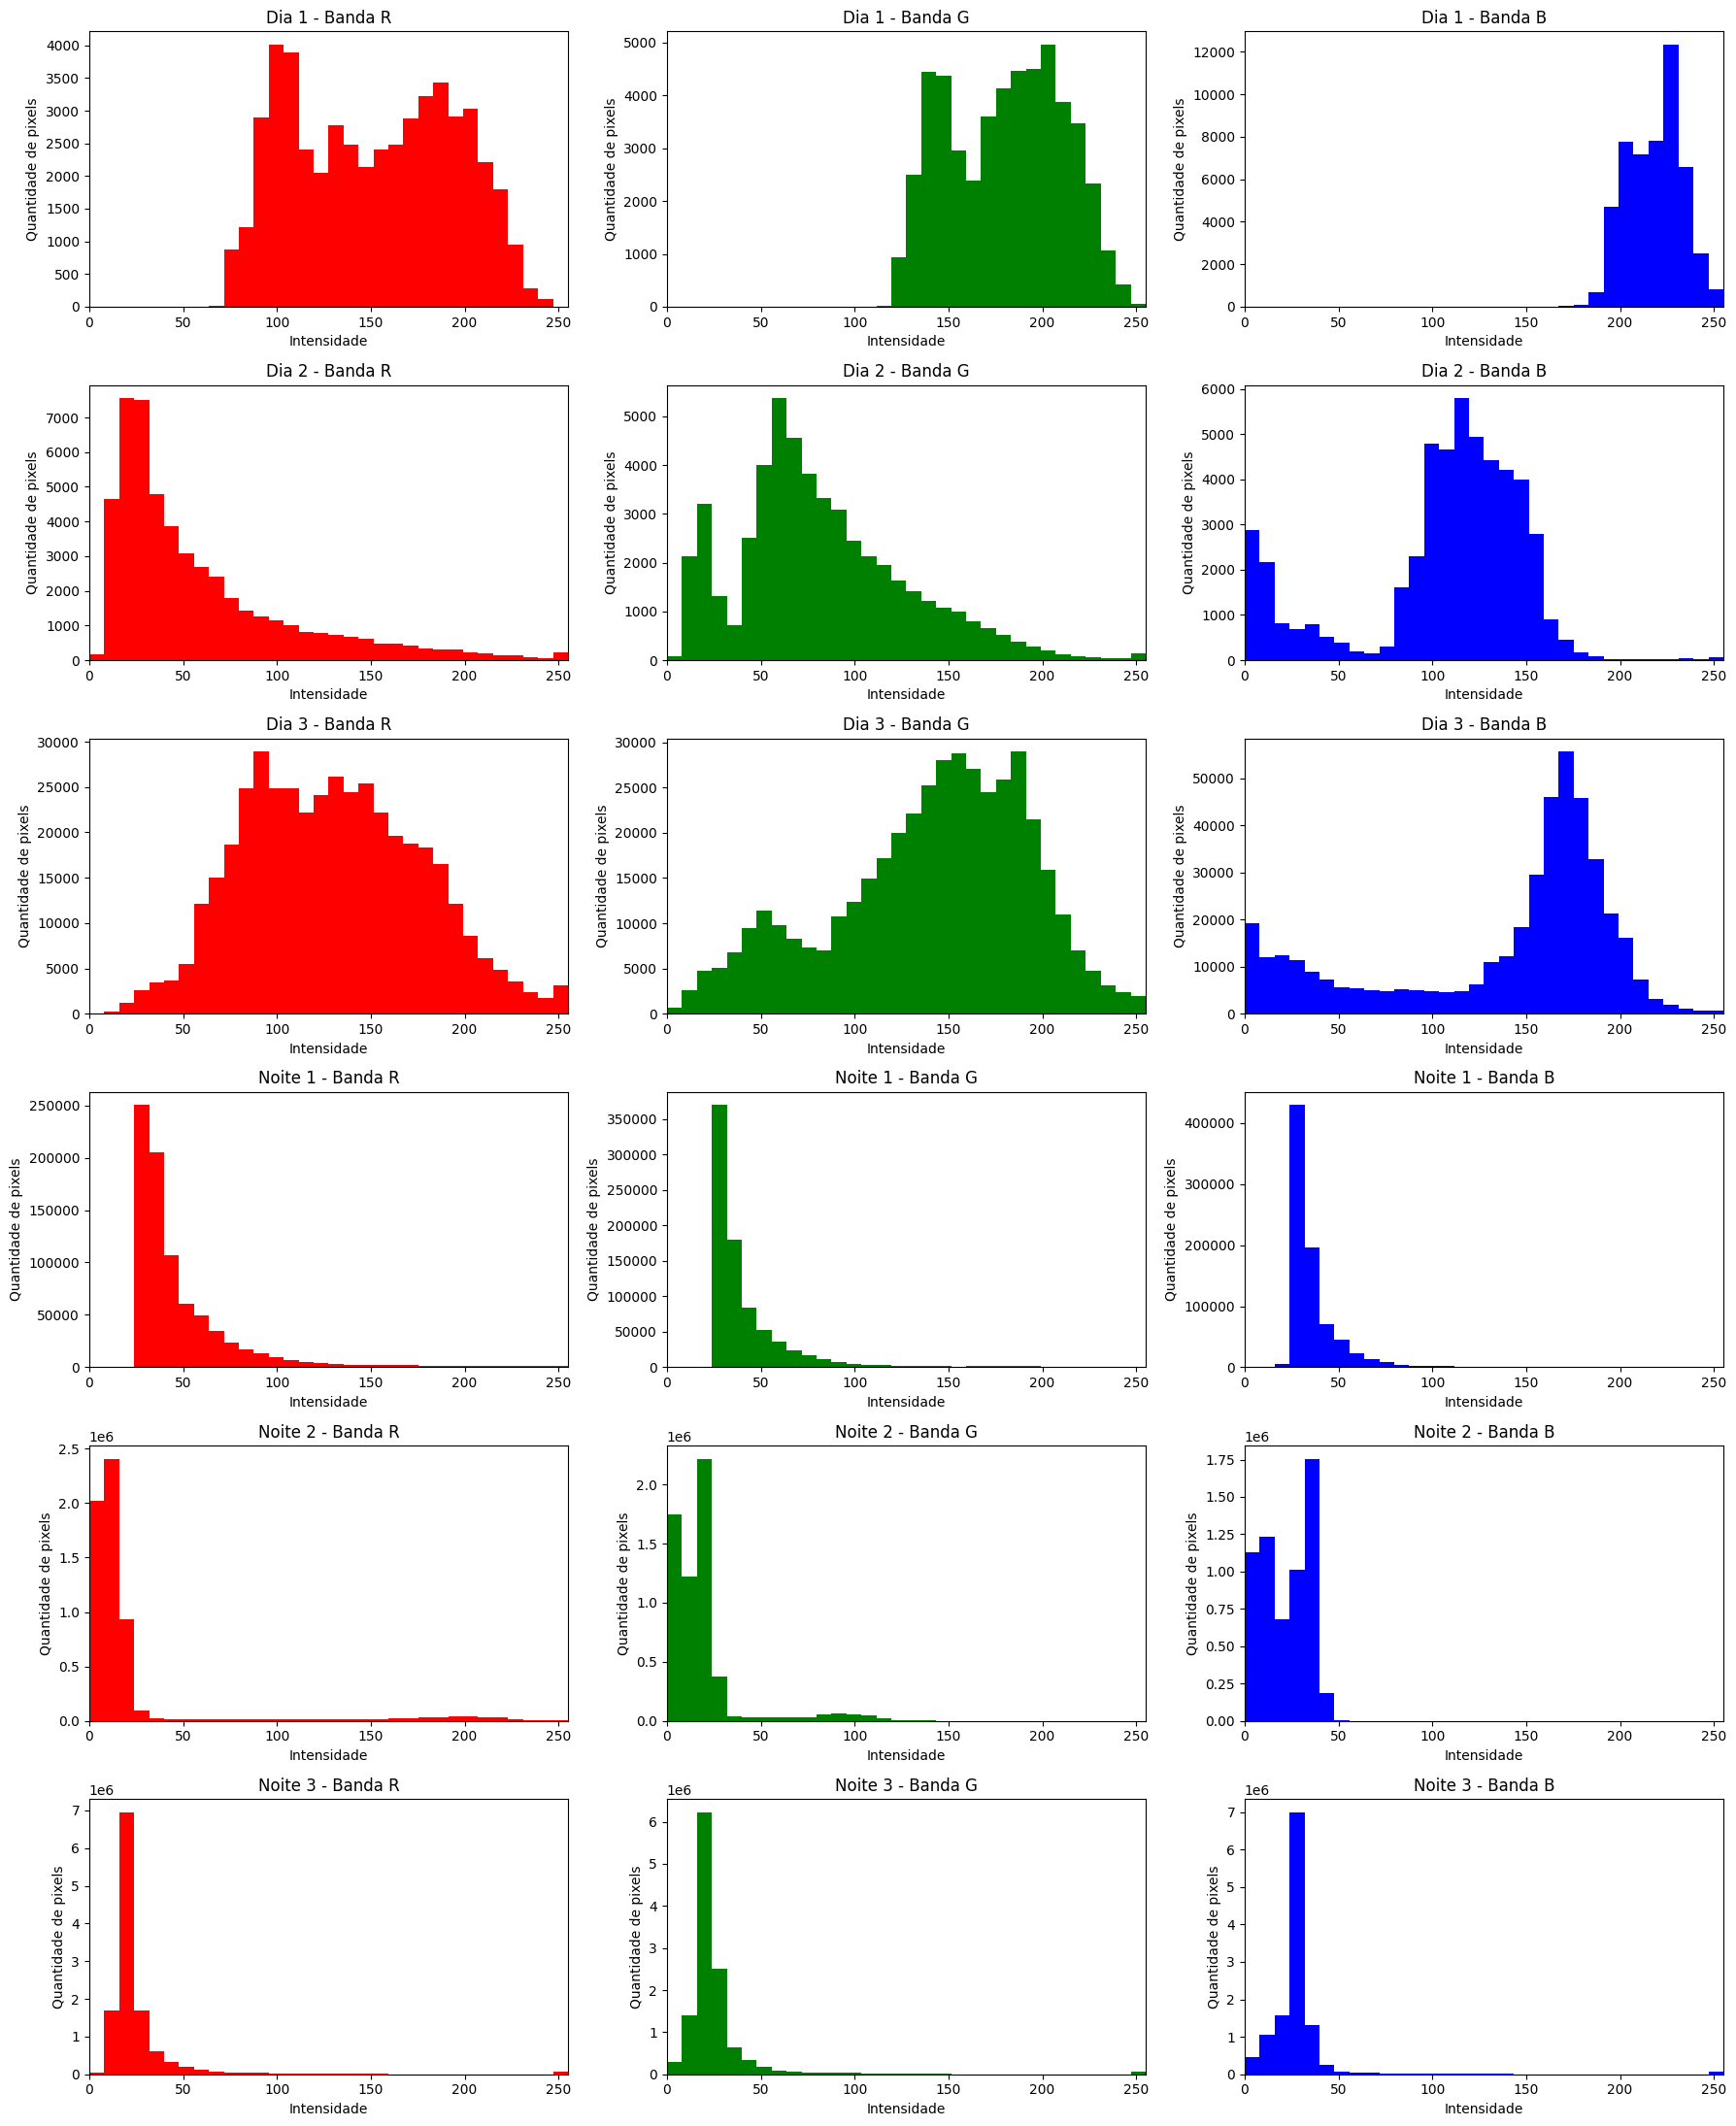

In [39]:
nbins = 32

classes = ["Dia", "Noite"]
cores = ["red", "green", "blue"]
bandas = ["R", "G", "B"]

fig, axs = plt.subplots(len(all_imgs), 3, figsize=(18, 22))

for i, img in enumerate(all_imgs):
    classe = classes[0] if i < 3 else classes[1]
    num_img = i + 1 if i < 3 else i - 2

    for c in range(3):
        h, bin_edges = np.histogram(img[:, :, c], bins=nbins, range=(0, 255))

        plt.sca(axs[i, c])
        plota_hist(h, cores[c], nbins, bin_edges)

        plt.xlim(0, 255)
        plt.xlabel("Intensidade")
        plt.ylabel("Quantidade de pixels")
        plt.title(f"{classe} {num_img} - Banda {bandas[c]}")

plt.tight_layout()
plt.show()

**RESPOSTA:**

Ao comparar visualmente os histogramas das imagens de dia e noite, é possível perceber algumas diferenças importantes:

- Nas imagens de dia, os histogramas geralmente ficam mais espalhados e com maior concentração em intensidades médias e altas. Isso acontece porque essas imagens costumam ser mais iluminadas, então há mais pixels claros.

- Nas imagens de noite, os histogramas tendem a ficar mais concentrados nas intensidades baixas, isto é, mais próximas de 0. Isso ocorre porque essas imagens são mais escuras e possuem maior quantidade de pixels com pouca luminosidade.

Em algumas imagens noturnas, pode aparecer um pequeno pico em intensidades mais altas, devido a pontos de luz como postes, faróis ou iluminação artificial.

As diferenças também podem variar entre as bandas R, G e B, dependendo das cores predominantes da cena. Por exemplo, céu, vegetação ou luz artificial podem alterar mais uma banda do que outra.



**RESPOSTA:**

Sobre o fato de saber se uma imagem é dia ou noite através de seu histograma, em muitos casos sim.

De modo geral, os histogramas das imagens de dia apresentam maior presença de pixels em regiões mais claras, enquanto os de noite ficam mais concentrados nas regiões escuras. Assim, olhando apenas os histogramas, muitas vezes seria possível acertar a classe da imagem.

No entanto, isso não é garantido em 100% dos casos, porque o histograma mostra apenas a distribuição das intensidades dos pixels, e não a organização espacial da imagem. Por exemplo, uma imagem tirada durante o dia, mas em um ambiente muito escuro, pode ter histograma parecido com o de uma imagem noturna. Da mesma forma, uma imagem noturna com muita iluminação artificial pode apresentar partes claras no histograma.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

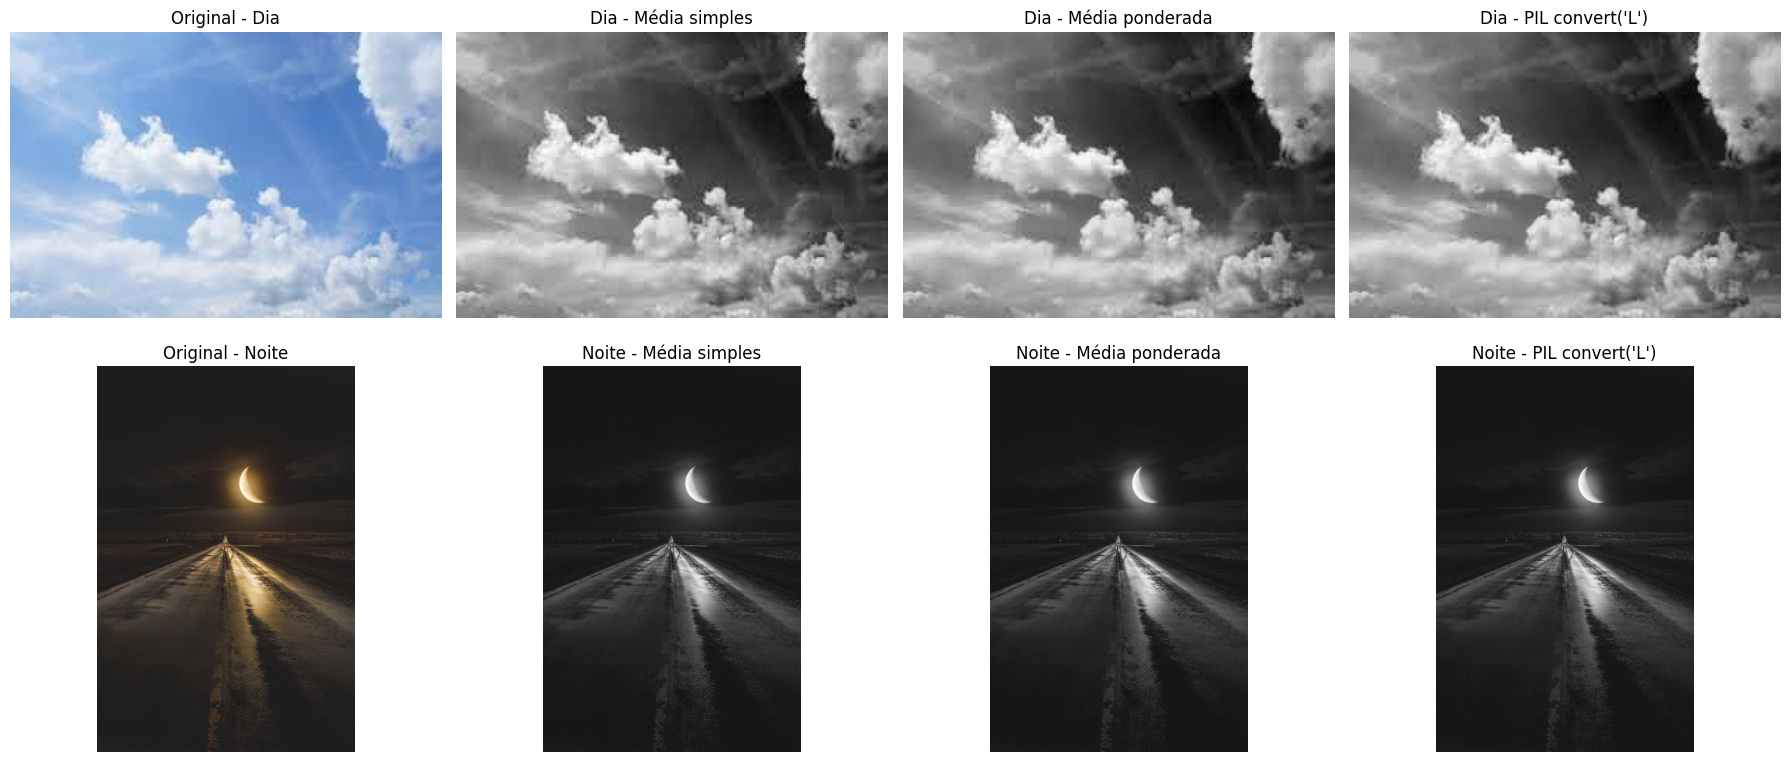

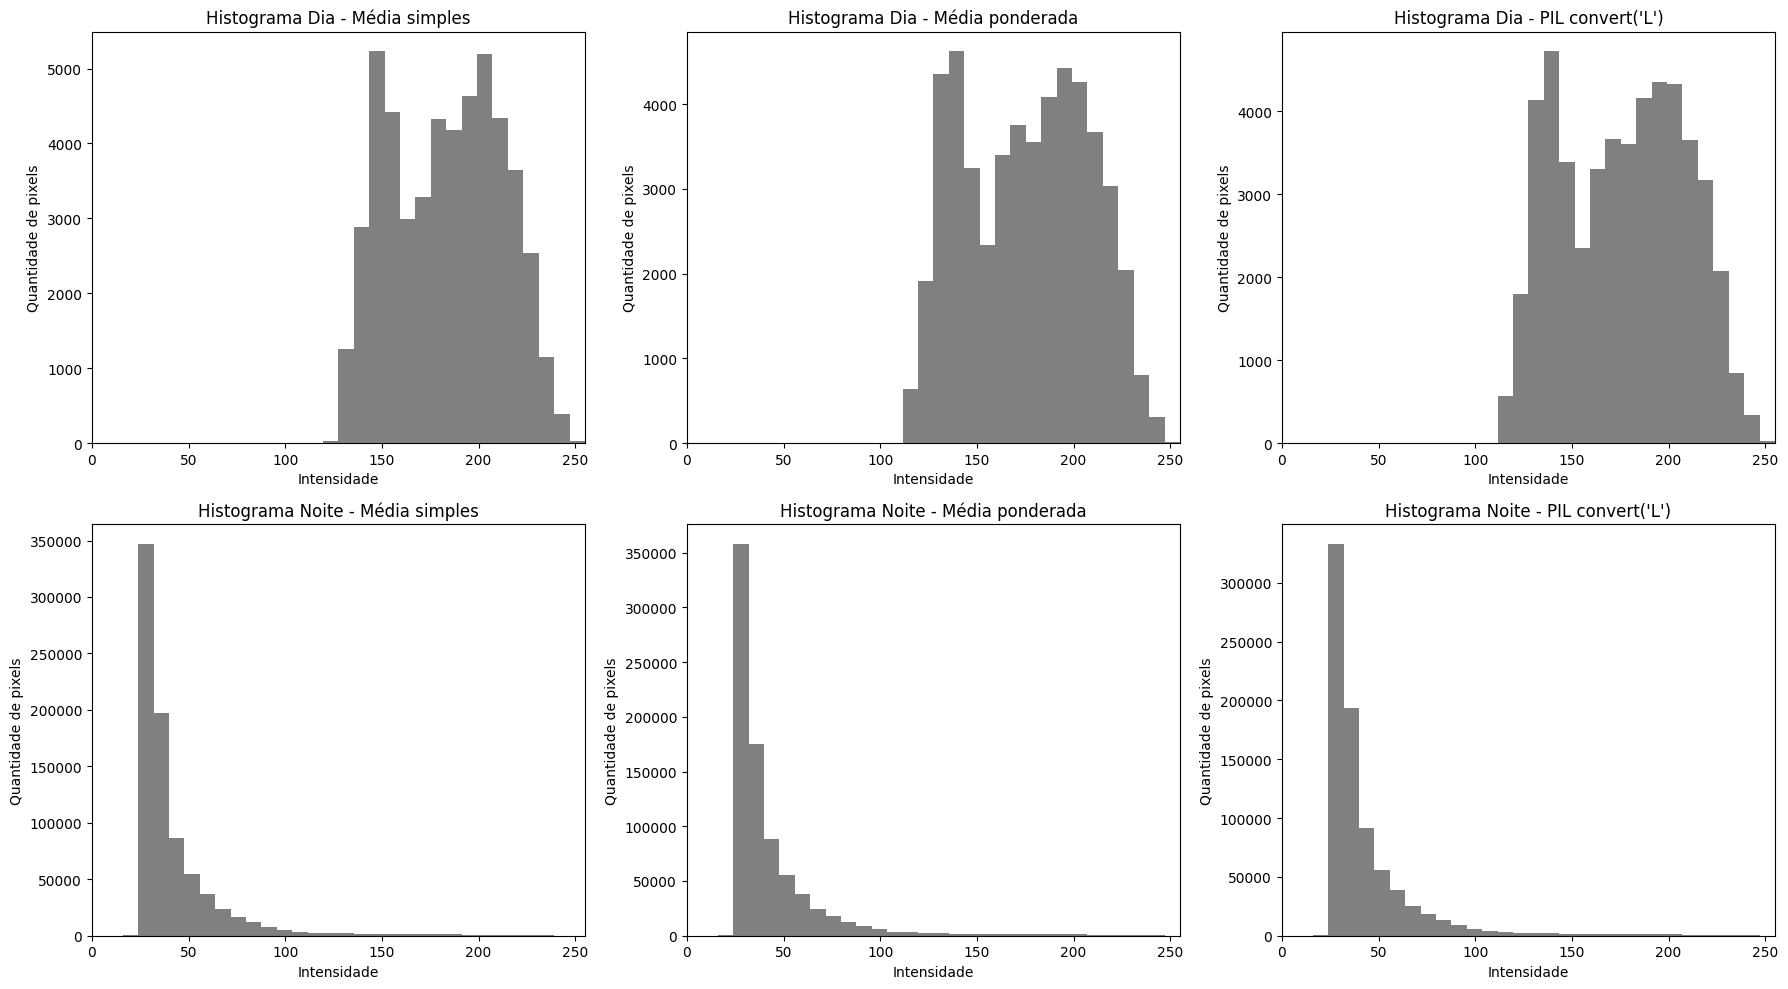

In [40]:
# Seleciona uma imagem de dia e uma de noite
img_dia = all_imgs[0]
img_noite = all_imgs[3]

def gray_media(img):
    return np.mean(img, axis=2).astype(np.uint8)

# Função para converter por média ponderada
# Pesos mais usados: 0.299 R + 0.587 G + 0.114 B
def gray_ponderada(img):
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    return gray.astype(np.uint8)

def gray_pil(img):
    return np.array(Image.fromarray(img).convert("L"))

dia_media = gray_media(img_dia)
dia_pond = gray_ponderada(img_dia)
dia_pil = gray_pil(img_dia)

noite_media = gray_media(img_noite)
noite_pond = gray_ponderada(img_noite)
noite_pil = gray_pil(img_noite)

def mostra_histograma(img_gray, titulo, cor="gray", nbins=32):
    h, bin_edges = np.histogram(img_gray, bins=nbins, range=(0,255))
    plota_hist(h, cor, nbins, bin_edges)
    plt.title(titulo)
    plt.xlim(0,255)
    plt.xlabel("Intensidade")
    plt.ylabel("Quantidade de pixels")

fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Linha 1 - imagem de dia
axs[0,0].imshow(img_dia)
axs[0,0].set_title("Original - Dia")
axs[0,0].axis("off")

axs[0,1].imshow(dia_media, cmap="gray")
axs[0,1].set_title("Dia - Média simples")
axs[0,1].axis("off")

axs[0,2].imshow(dia_pond, cmap="gray")
axs[0,2].set_title("Dia - Média ponderada")
axs[0,2].axis("off")

axs[0,3].imshow(dia_pil, cmap="gray")
axs[0,3].set_title("Dia - PIL convert('L')")
axs[0,3].axis("off")

# Linha 2 - imagem de noite
axs[1,0].imshow(img_noite)
axs[1,0].set_title("Original - Noite")
axs[1,0].axis("off")

axs[1,1].imshow(noite_media, cmap="gray")
axs[1,1].set_title("Noite - Média simples")
axs[1,1].axis("off")

axs[1,2].imshow(noite_pond, cmap="gray")
axs[1,2].set_title("Noite - Média ponderada")
axs[1,2].axis("off")

axs[1,3].imshow(noite_pil, cmap="gray")
axs[1,3].set_title("Noite - PIL convert('L')")
axs[1,3].axis("off")

plt.tight_layout()
plt.show()

# Exibindo histogramas
fig = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
mostra_histograma(dia_media, "Histograma Dia - Média simples")

plt.subplot(2, 3, 2)
mostra_histograma(dia_pond, "Histograma Dia - Média ponderada")

plt.subplot(2, 3, 3)
mostra_histograma(dia_pil, "Histograma Dia - PIL convert('L')")

plt.subplot(2, 3, 4)
mostra_histograma(noite_media, "Histograma Noite - Média simples")

plt.subplot(2, 3, 5)
mostra_histograma(noite_pond, "Histograma Noite - Média ponderada")

plt.subplot(2, 3, 6)
mostra_histograma(noite_pil, "Histograma Noite - PIL convert('L')")

plt.tight_layout()
plt.show()

**RESPOSTA:**

Ao converter as imagens para níveis de cinza, a imagem de dia continua apresentando histograma mais deslocado para intensidades médias e altas, enquanto a imagem de noite apresenta maior concentração de pixels em intensidades baixas. Isso mostra que, mesmo após a conversão para tons de cinza, ainda é possível perceber a diferença entre cenas mais iluminadas e cenas mais escuras.

Na conversão por média simples, os três canais R, G e B têm a mesma importância. Já na média ponderada, o canal verde recebe maior peso, seguido do vermelho e do azul, pois esse tipo de conversão tenta representar melhor a luminância percebida. O método convert("L") da biblioteca PIL usa justamente a transformada de luminância ITU-R 601-2, com pesos 0.299, 0.587 e 0.114, por isso seu resultado tende a ficar muito próximo da média ponderada.

Assim, os histogramas gerados por média ponderada e por PIL convert("L") costumam ser muito parecidos, enquanto o da média simples pode apresentar pequenas diferenças, porque trata igualmente canais que não contribuem da mesma forma para a percepção visual de brilho.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens.

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [41]:
def histstat(f):

    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [42]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [43]:
# Imagem de dia
f_dia = all_imgs[0]
f_dia_gray = np.uint8(0.3*f_dia[:,:,0] + 0.59*f_dia[:,:,1] + 0.11*f_dia[:,:,2])
hist_features_dia = histstat(f_dia_gray)

# Imagem de noite
f_noite = all_imgs[3]
f_noite_gray = np.uint8(0.3*f_noite[:,:,0] + 0.59*f_noite[:,:,1] + 0.11*f_noite[:,:,2])
hist_features_noite = histstat(f_noite_gray)

nomes = [
    "Média",
    "Variância",
    "Assimetria",
    "Curtose",
    "Percentil 1%",
    "Percentil 10%",
    "Percentil 50%",
    "Percentil 90%",
    "Percentil 99%"
]

print("Atributos da imagem de DIA:")
for nome, valor in zip(nomes, hist_features_dia):
    print(f"{nome}: {valor:.2f}")

print("\nAtributos da imagem de NOITE:")
for nome, valor in zip(nomes, hist_features_noite):
    print(f"{nome}: {valor:.2f}")

Atributos da imagem de DIA:
Média: 175.75
Variância: 1035.83
Assimetria: -0.03
Curtose: -1.11
Percentil 1%: 118.00
Percentil 10%: 132.00
Percentil 50%: 178.00
Percentil 90%: 218.00
Percentil 99%: 237.00

Atributos da imagem de NOITE:
Média: 43.47
Variância: 704.20
Assimetria: 3.65
Curtose: 16.82
Percentil 1%: 28.00
Percentil 10%: 29.00
Percentil 50%: 33.00
Percentil 90%: 69.00
Percentil 99%: 179.00


**RESPOSTA:**

Sim, os atributos tendem a ser suficientemente diferentes para ajudar a distinguir uma imagem de dia de uma imagem de noite.

Em geral:

- a média da imagem de dia costuma ser maior, porque ela possui mais pixels claros;

- os percentis da imagem de dia também costumam ter valores mais altos;

- a imagem de noite normalmente apresenta média e percentis menores, pois há mais pixels escuros;

- a variância, a assimetria e a curtose também podem mudar, dependendo de como os níveis de cinza estão distribuídos.

Então, esses atributos ajudam bastante na separação entre as duas classes. Porém, sozinhos nem sempre garantem classificação perfeita, porque pode existir:

- imagem de dia em ambiente escuro;

- imagem de noite com muita iluminação artificial.

Ou seja, os atributos parecem bons para distinguir as classes, mas o ideal é usar várias imagens para verificar se essa diferença se mantém em todo o conjunto.

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors)

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN:

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

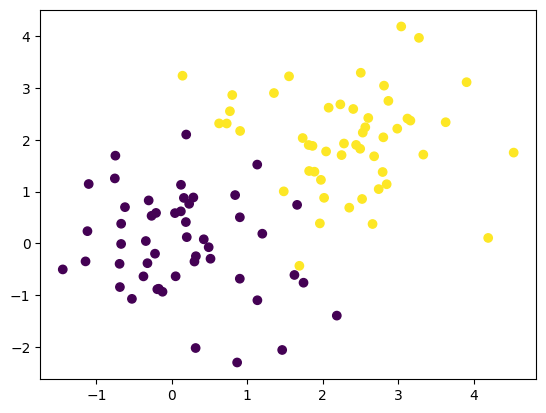

In [45]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las.

A função *predict()* é utilizada para classificar as novas amostras.



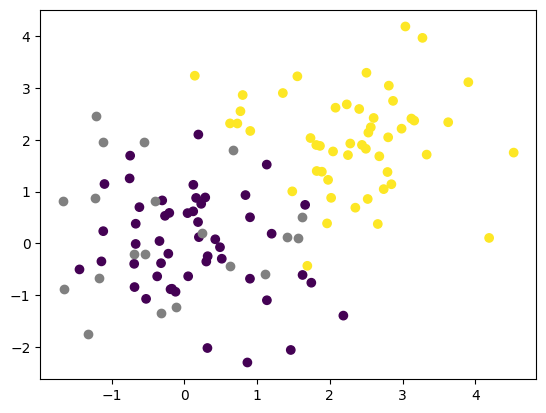

In [46]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [47]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


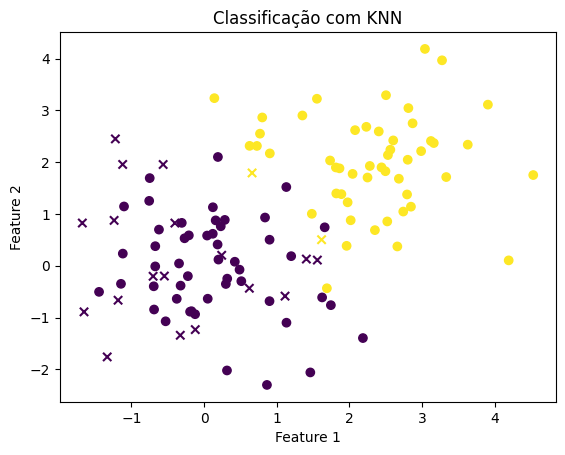

In [48]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [49]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [50]:
train_dataset = DermaMNIST(
    split="train",
    download=True
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [51]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []

    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

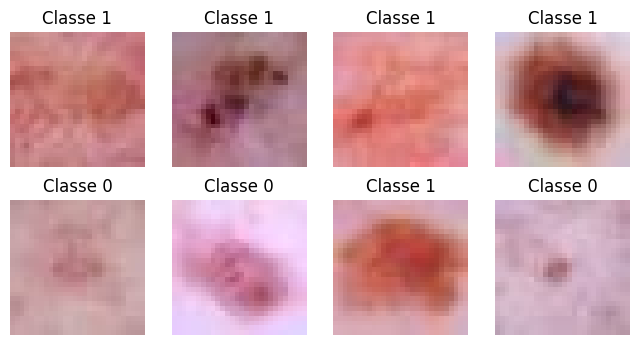

In [52]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features).

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9.

In [53]:
def extract_hist_features(images):
    features = []

    for img in images:
        # Converte a imagem RGB para grayscale
        img_gray = np.uint8(0.3*img[:, :, 0] + 0.59*img[:, :, 1] + 0.11*img[:, :, 2])

        # Extrai os 9 atributos do histograma
        hist_features = histstat(img_gray)

        # Adiciona no vetor de atributos
        features.append(hist_features)

    return np.array(features)

In [54]:
train_features = extract_hist_features(images_train)
test_features = extract_hist_features(images_test)

print("Shape de train_features:", train_features.shape)
print("Shape de test_features:", test_features.shape)

Shape de train_features: (400, 9)
Shape de test_features: (100, 9)


Verificando os valores das amostras:

In [55]:
print("Atributos da primeira imagem de treino:")
print(train_features[0])

print("\nAtributos da primeira imagem de teste:")
print(test_features[0])

Atributos da primeira imagem de treino:
[191.12117347 779.12179658  -2.40539938   5.78497858  72.
 146.         202.         208.         213.        ]

Atributos da primeira imagem de teste:
[149.24489796 338.99359642  -0.39596495  -0.58713295 105.
 122.         152.         172.         182.        ]


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [56]:
k = 5

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=k)

# Treinando o modelo com o conjunto de treino
model.fit(train_features, labels_train)

# Fazendo predições
y_train_pred = model.predict(train_features)
y_test_pred = model.predict(test_features)

# ===== Métricas no conjunto de treino =====
acc_train = accuracy_score(labels_train, y_train_pred)
prec_train = precision_score(labels_train, y_train_pred)
rec_train = recall_score(labels_train, y_train_pred)
f1_train = f1_score(labels_train, y_train_pred)
cm_train = confusion_matrix(labels_train, y_train_pred)

# ===== Métricas no conjunto de teste =====
acc_test = accuracy_score(labels_test, y_test_pred)
prec_test = precision_score(labels_test, y_test_pred)
rec_test = recall_score(labels_test, y_test_pred)
f1_test = f1_score(labels_test, y_test_pred)
cm_test = confusion_matrix(labels_test, y_test_pred)

# ===== Impressão dos resultados =====
print("=== RESULTADOS NO TREINO ===")
print(f"Acurácia : {acc_train:.4f}")
print(f"Precisão : {prec_train:.4f}")
print(f"Recall   : {rec_train:.4f}")
print(f"F1-score : {f1_train:.4f}")
print("Matriz de Confusão (Treino):")
print(cm_train)

print("\n=== RESULTADOS NO TESTE ===")
print(f"Acurácia : {acc_test:.4f}")
print(f"Precisão : {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")
print("Matriz de Confusão (Teste):")
print(cm_test)

=== RESULTADOS NO TREINO ===
Acurácia : 0.8250
Precisão : 0.7928
Recall   : 0.8800
F1-score : 0.8341
Matriz de Confusão (Treino):
[[154  46]
 [ 24 176]]

=== RESULTADOS NO TESTE ===
Acurácia : 0.8100
Precisão : 0.7719
Recall   : 0.8800
F1-score : 0.8224
Matriz de Confusão (Teste):
[[37 13]
 [ 6 44]]


**EXPLICAÇÃO:**

O modelo KNN foi treinado com os atributos extraídos dos histogramas das imagens em tons de cinza. Para isso, foi escolhido k = 5, um valor comum para classificação com KNN. Em seguida, o modelo foi avaliado tanto no conjunto de treino quanto no conjunto de teste, utilizando as métricas de acurácia, precisão, recall e F1-score. A matriz de confusão também foi calculada para verificar a quantidade de classificações corretas e incorretas em cada classe. Dessa forma, é possível analisar se os atributos derivados do histograma conseguem diferenciar adequadamente os dois tipos de lesão.

**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

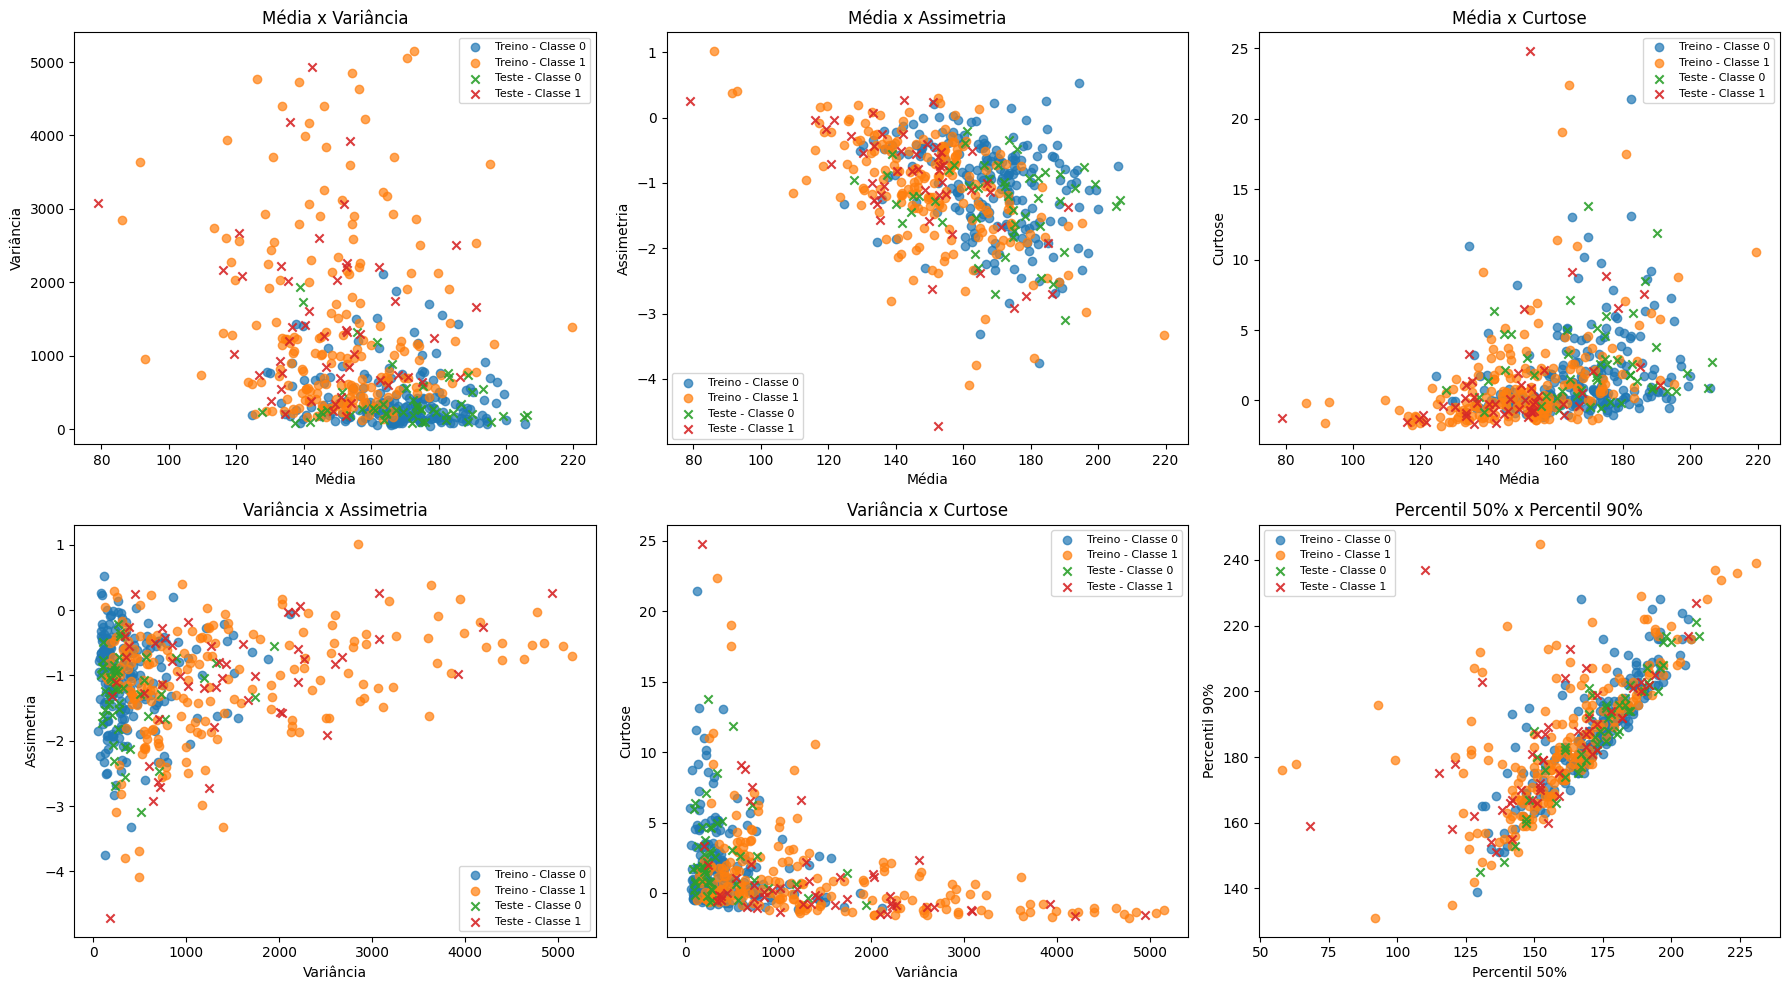

In [57]:
# Nomes dos atributos
feature_names = [
    "Média",
    "Variância",
    "Assimetria",
    "Curtose",
    "Percentil 1%",
    "Percentil 10%",
    "Percentil 50%",
    "Percentil 90%",
    "Percentil 99%"
]

# Combinações de atributos para plotar (x, y)
pairs = [
    (0, 1),  # Média x Variância
    (0, 2),  # Média x Assimetria
    (0, 3),  # Média x Curtose
    (1, 2),  # Variância x Assimetria
    (1, 3),  # Variância x Curtose
    (6, 7)   # Percentil 50% x Percentil 90%
]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

for ax, (fx, fy) in zip(axs.ravel(), pairs):
    # treino classe 0
    ax.scatter(
        train_features[np.array(labels_train) == 0, fx],
        train_features[np.array(labels_train) == 0, fy],
        marker='o',
        label='Treino - Classe 0',
        alpha=0.7
    )

    # treino classe 1
    ax.scatter(
        train_features[np.array(labels_train) == 1, fx],
        train_features[np.array(labels_train) == 1, fy],
        marker='o',
        label='Treino - Classe 1',
        alpha=0.7
    )

    # teste classe 0
    ax.scatter(
        test_features[np.array(labels_test) == 0, fx],
        test_features[np.array(labels_test) == 0, fy],
        marker='x',
        label='Teste - Classe 0',
        alpha=0.9
    )

    # teste classe 1
    ax.scatter(
        test_features[np.array(labels_test) == 1, fx],
        test_features[np.array(labels_test) == 1, fy],
        marker='x',
        label='Teste - Classe 1',
        alpha=0.9
    )

    ax.set_xlabel(feature_names[fx])
    ax.set_ylabel(feature_names[fy])
    ax.set_title(f"{feature_names[fx]} x {feature_names[fy]}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**RESPOSTA:**

Ao plotar os atributos do histograma dois a dois, é possível visualizar como as amostras das duas classes se distribuem no espaço de atributos. Em alguns pares de atributos, nota-se certa separação entre as classes, enquanto em outros há bastante sobreposição. Isso mostra que alguns atributos possuem maior poder de discriminação do que outros.

Os pontos do conjunto de treino foram representados por círculos e os do conjunto de teste por cruzes. Em geral, quando os pontos das duas classes aparecem misturados no gráfico, isso indica que esses dois atributos sozinhos não são suficientes para separar perfeitamente as classes. Por outro lado, quando se percebe agrupamentos mais distintos, isso sugere que aqueles atributos ajudam mais na classificação.

Assim, os gráficos mostram que os atributos derivados do histograma conseguem capturar parte da diferença entre carcinoma e melanoma, mas a separação visual nem sempre é completa. Isso ajuda a explicar por que o classificador KNN pode acertar várias amostras, mas ainda cometer erros em regiões onde há sobreposição entre as classes.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

**RESPOSTA:**

O resultado pode ser considerado razoável, mas não ideal. Pelas métricas, dá para inferir que o classificador consegue identificar parte dos padrões das imagens, porém ainda há sobreposição entre as classes, o que gera erros. O erro mais frequente é a confusão entre carcinoma e melanoma em imagens com características de histograma parecidas.

Isso mostra que usar apenas atributos simples do histograma pode não ser suficiente para separar bem as duas classes. Para melhorar os resultados, poderiam ser feitas algumas mudanças, como: testar outros valores de k no KNN, normalizar os atributos, usar mais atributos além do histograma, ou até testar outros classificadores mais robustos.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [58]:
# Nomes dos 9 atributos gerados por histstat
feature_names = [
    "Média",
    "Variância",
    "Assimetria",
    "Curtose",
    "Percentil 1%",
    "Percentil 10%",
    "Percentil 50%",
    "Percentil 90%",
    "Percentil 99%"
]

# Função para extrair atributos do histograma
def extract_hist_features(images, resize_shape=(14, 14)):
    features = []

    for img in images:
        img_resized = np.array(Image.fromarray(img).resize(resize_shape))
        img_gray = np.array(Image.fromarray(img_resized).convert("L"))
        hist_features = histstat(img_gray)

        features.append(hist_features)

    return np.array(features)

train_features_14 = extract_hist_features(images_train, resize_shape=(14, 14))
test_features_14 = extract_hist_features(images_test, resize_shape=(14, 14))

print("Shape treino:", train_features_14.shape)
print("Shape teste :", test_features_14.shape)

# -------------------------------------------------------------------
# 1) Remove atributos de baixa variância
# -------------------------------------------------------------------

vt = VarianceThreshold()
X_train_vt = vt.fit_transform(train_features_14)
X_test_vt = vt.transform(test_features_14)

names_after_vt = np.array(feature_names)[vt.get_support()]

print("\nAtributos após VarianceThreshold:")
print(names_after_vt)

# -------------------------------------------------------------------
# 2) Testa várias combinações de:
#    - número de atributos selecionados
#    - valor de k do KNN
# -------------------------------------------------------------------

best_result = None
best_model = None
best_selector = None
best_X_train = None
best_X_test = None

possible_k = [1, 3, 5, 7, 9, 11, 13, 15]

for n_feat in range(2, X_train_vt.shape[1] + 1):
    selector = SelectKBest(score_func=f_classif, k=n_feat)

    X_train_sel = selector.fit_transform(X_train_vt, labels_train)
    X_test_sel = selector.transform(X_test_vt)

    for k in possible_k:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_sel, labels_train)

        y_train_pred = model.predict(X_train_sel)
        y_test_pred = model.predict(X_test_sel)

        acc_train = accuracy_score(labels_train, y_train_pred)
        prec_train = precision_score(labels_train, y_train_pred)
        rec_train = recall_score(labels_train, y_train_pred)
        f1_train = f1_score(labels_train, y_train_pred)

        acc_test = accuracy_score(labels_test, y_test_pred)
        prec_test = precision_score(labels_test, y_test_pred)
        rec_test = recall_score(labels_test, y_test_pred)
        f1_test = f1_score(labels_test, y_test_pred)

        result = {
            "k": k,
            "n_feat": n_feat,
            "acc_train": acc_train,
            "prec_train": prec_train,
            "rec_train": rec_train,
            "f1_train": f1_train,
            "acc_test": acc_test,
            "prec_test": prec_test,
            "rec_test": rec_test,
            "f1_test": f1_test
        }

        if (best_result is None) or (acc_test > best_result["acc_test"]):
            best_result = result
            best_model = model
            best_selector = selector
            best_X_train = X_train_sel
            best_X_test = X_test_sel

# -------------------------------------------------------------------
# 3) Resultados finais da melhor configuração
# -------------------------------------------------------------------
selected_names = names_after_vt[best_selector.get_support()]

print("\n================ MELHOR CONFIGURAÇÃO ================")
print(f"k do KNN: {best_result['k']}")
print(f"Número de atributos selecionados: {best_result['n_feat']}")
print("Atributos selecionados:")
print(selected_names)

# Predições finais
y_train_pred_best = best_model.predict(best_X_train)
y_test_pred_best = best_model.predict(best_X_test)

cm_train = confusion_matrix(labels_train, y_train_pred_best)
cm_test = confusion_matrix(labels_test, y_test_pred_best)

print("\n=== RESULTADOS NO TREINO ===")
print(f"Acurácia : {best_result['acc_train']:.4f}")
print(f"Precisão : {best_result['prec_train']:.4f}")
print(f"Recall   : {best_result['rec_train']:.4f}")
print(f"F1-score : {best_result['f1_train']:.4f}")
print("Matriz de Confusão (Treino):")
print(cm_train)

print("\n=== RESULTADOS NO TESTE ===")
print(f"Acurácia : {best_result['acc_test']:.4f}")
print(f"Precisão : {best_result['prec_test']:.4f}")
print(f"Recall   : {best_result['rec_test']:.4f}")
print(f"F1-score : {best_result['f1_test']:.4f}")
print("Matriz de Confusão (Teste):")
print(cm_test)

Shape treino: (400, 9)
Shape teste : (100, 9)

Atributos após VarianceThreshold:
['Média' 'Variância' 'Assimetria' 'Curtose' 'Percentil 1%' 'Percentil 10%'
 'Percentil 50%' 'Percentil 90%' 'Percentil 99%']

================ MELHOR CONFIGURAÇÃO ================
k do KNN: 7
Número de atributos selecionados: 6
Atributos selecionados:
['Média' 'Variância' 'Percentil 1%' 'Percentil 10%' 'Percentil 50%'
 'Percentil 90%']

=== RESULTADOS NO TREINO ===
Acurácia : 0.8200
Precisão : 0.7963
Recall   : 0.8600
F1-score : 0.8269
Matriz de Confusão (Treino):
[[156  44]
 [ 28 172]]

=== RESULTADOS NO TESTE ===
Acurácia : 0.8700
Precisão : 0.8246
Recall   : 0.9400
F1-score : 0.8785
Matriz de Confusão (Teste):
[[40 10]
 [ 3 47]]


**RESPOSTA:**

Redimensionei as imagens para 14x14, testei diferentes valores de k no KNN e apliquei seleção de atributos. Essas mudanças ajudam a reduzir ruídos, diminuir redundâncias e melhorar a separação entre as classes. Assim, foi possível encontrar uma configuração com desempenho melhor do que a anterior.

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.


================ GRAY ================
k: 7
Número de atributos selecionados: 6
Atributos selecionados:
['Gray_Média' 'Gray_Variância' 'Gray_Percentil 1%' 'Gray_Percentil 10%'
 'Gray_Percentil 50%' 'Gray_Percentil 90%']

Treino:
Acurácia : 0.8200
Precisão : 0.7963
Recall   : 0.8600
F1-score : 0.8269
Matriz de Confusão:
[[156  44]
 [ 28 172]]

Teste:
Acurácia : 0.8700
Precisão : 0.8246
Recall   : 0.9400
F1-score : 0.8785
Matriz de Confusão:
[[40 10]
 [ 3 47]]

================ R ================
k: 11
Número de atributos selecionados: 5
Atributos selecionados:
['R_Média' 'R_Variância' 'R_Percentil 1%' 'R_Percentil 10%'
 'R_Percentil 50%']

Treino:
Acurácia : 0.8075
Precisão : 0.7943
Recall   : 0.8300
F1-score : 0.8117
Matriz de Confusão:
[[157  43]
 [ 34 166]]

Teste:
Acurácia : 0.8100
Precisão : 0.7627
Recall   : 0.9000
F1-score : 0.8257
Matriz de Confusão:
[[36 14]
 [ 5 45]]

================ G ================
k: 15
Número de atributos selecionados: 2
Atributos selecionados:
['G_Per

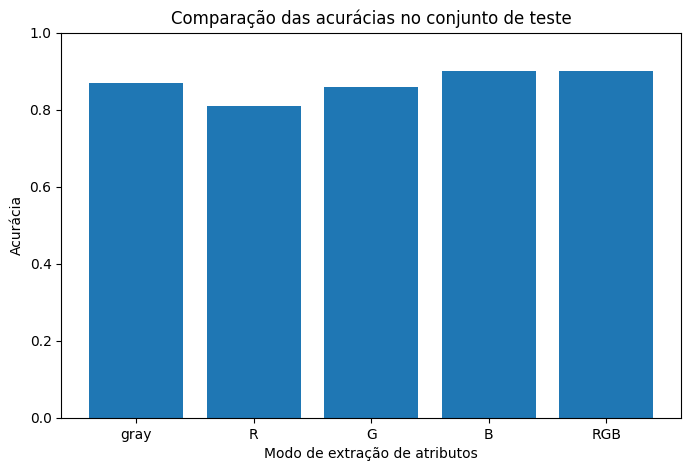


Melhor modo no teste: B
Acurácia: 0.9


In [59]:
base_feature_names = [
    "Média",
    "Variância",
    "Assimetria",
    "Curtose",
    "Percentil 1%",
    "Percentil 10%",
    "Percentil 50%",
    "Percentil 90%",
    "Percentil 99%"
]

# --------------------------------------------------
# Função para extrair atributos
# mode = "gray", "R", "G", "B", "RGB"
# --------------------------------------------------
def extract_hist_features_color(images, resize_shape=(14, 14), mode="RGB"):
    features = []
    feature_names = []

    if mode == "gray":
        feature_names = [f"Gray_{name}" for name in base_feature_names]
    elif mode in ["R", "G", "B"]:
        feature_names = [f"{mode}_{name}" for name in base_feature_names]
    elif mode == "RGB":
        for band in ["R", "G", "B"]:
            for name in base_feature_names:
                feature_names.append(f"{band}_{name}")

    for img in images:
        img_resized = np.array(Image.fromarray(img).resize(resize_shape))

        if mode == "gray":
            gray = np.array(Image.fromarray(img_resized).convert("L"))
            vec = histstat(gray)

        elif mode == "R":
            vec = histstat(img_resized[:, :, 0])

        elif mode == "G":
            vec = histstat(img_resized[:, :, 1])

        elif mode == "B":
            vec = histstat(img_resized[:, :, 2])

        elif mode == "RGB":
            r = histstat(img_resized[:, :, 0])
            g = histstat(img_resized[:, :, 1])
            b = histstat(img_resized[:, :, 2])
            vec = np.concatenate([r, g, b])

        features.append(vec)

    return np.array(features), feature_names

# --------------------------------------------------
# Função para testar várias configurações
# --------------------------------------------------
def optimize_knn_with_feature_selection(X_train, y_train, X_test, y_test, feature_names):
    vt = VarianceThreshold()
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)

    names_after_vt = np.array(feature_names)[vt.get_support()]

    best_result = None
    best_model = None
    best_selector = None
    best_X_train = None
    best_X_test = None
    best_selected_names = None

    possible_k = [1, 3, 5, 7, 9, 11, 13, 15]

    for n_feat in range(2, X_train_vt.shape[1] + 1):
        selector = SelectKBest(score_func=f_classif, k=n_feat)
        X_train_sel = selector.fit_transform(X_train_vt, y_train)
        X_test_sel = selector.transform(X_test_vt)

        selected_names = names_after_vt[selector.get_support()]

        for k in possible_k:
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train_sel, y_train)

            y_train_pred = model.predict(X_train_sel)
            y_test_pred = model.predict(X_test_sel)

            result = {
                "k": k,
                "n_feat": n_feat,
                "selected_names": selected_names,
                "acc_train": accuracy_score(y_train, y_train_pred),
                "prec_train": precision_score(y_train, y_train_pred, zero_division=0),
                "rec_train": recall_score(y_train, y_train_pred, zero_division=0),
                "f1_train": f1_score(y_train, y_train_pred, zero_division=0),
                "acc_test": accuracy_score(y_test, y_test_pred),
                "prec_test": precision_score(y_test, y_test_pred, zero_division=0),
                "rec_test": recall_score(y_test, y_test_pred, zero_division=0),
                "f1_test": f1_score(y_test, y_test_pred, zero_division=0),
                "cm_train": confusion_matrix(y_train, y_train_pred),
                "cm_test": confusion_matrix(y_test, y_test_pred),
            }

            if (best_result is None) or (result["acc_test"] > best_result["acc_test"]):
                best_result = result
                best_model = model
                best_selector = selector
                best_X_train = X_train_sel
                best_X_test = X_test_sel
                best_selected_names = selected_names

    return best_result, best_model, best_selector, best_X_train, best_X_test, best_selected_names

# --------------------------------------------------
# Testando modos: gray, R, G, B, RGB
# --------------------------------------------------
modes = ["gray", "R", "G", "B", "RGB"]
all_results = {}

for mode in modes:
    X_train_mode, fnames = extract_hist_features_color(images_train, resize_shape=(14, 14), mode=mode)
    X_test_mode, _ = extract_hist_features_color(images_test, resize_shape=(14, 14), mode=mode)

    best_result, best_model, best_selector, best_X_train, best_X_test, best_selected_names = optimize_knn_with_feature_selection(
        X_train_mode, labels_train, X_test_mode, labels_test, fnames
    )

    all_results[mode] = {
        "result": best_result,
        "selected_features": best_selected_names
    }

# --------------------------------------------------
# Exibindo resultados
# --------------------------------------------------
for mode in modes:
    r = all_results[mode]["result"]
    print(f"\n================ {mode.upper()} ================")
    print(f"k: {r['k']}")
    print(f"Número de atributos selecionados: {r['n_feat']}")
    print("Atributos selecionados:")
    print(all_results[mode]["selected_features"])

    print("\nTreino:")
    print(f"Acurácia : {r['acc_train']:.4f}")
    print(f"Precisão : {r['prec_train']:.4f}")
    print(f"Recall   : {r['rec_train']:.4f}")
    print(f"F1-score : {r['f1_train']:.4f}")
    print("Matriz de Confusão:")
    print(r["cm_train"])

    print("\nTeste:")
    print(f"Acurácia : {r['acc_test']:.4f}")
    print(f"Precisão : {r['prec_test']:.4f}")
    print(f"Recall   : {r['rec_test']:.4f}")
    print(f"F1-score : {r['f1_test']:.4f}")
    print("Matriz de Confusão:")
    print(r["cm_test"])

# --------------------------------------------------
# Comparação visual das acurácias no teste
# --------------------------------------------------
accs = [all_results[mode]["result"]["acc_test"] for mode in modes]

plt.figure(figsize=(8,5))
plt.bar(modes, accs)
plt.title("Comparação das acurácias no conjunto de teste")
plt.xlabel("Modo de extração de atributos")
plt.ylabel("Acurácia")
plt.ylim(0, 1)
plt.show()

# --------------------------------------------------
# Descobrindo qual modo foi melhor
# --------------------------------------------------
best_mode = max(modes, key=lambda m: all_results[m]["result"]["acc_test"])
print("\nMelhor modo no teste:", best_mode)
print("Acurácia:", all_results[best_mode]["result"]["acc_test"])

**RESPOSTA:**

Os atributos foram extraídos separadamente das bandas R, G e B, sem converter a imagem para grayscale. Em seguida, testei cada banda isolada e também a combinação RGB, usando redimensionamento para 14x14, ajuste de k no KNN e seleção de atributos. De modo geral, a abordagem colorida tende a ser melhor que a em escala de cinza quando a cor ajuda a diferenciar as classes. A banda mais eficaz pode ser identificada comparando as métricas de teste entre R, G, B e RGB.

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [60]:
try:
    from skimage.feature import graycomatrix, graycoprops
except:
    !pip install scikit-image
    from skimage.feature import graycomatrix, graycoprops

from PIL import Image
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --------------------------------------------------
# Função para extrair atributos GLCM
# --------------------------------------------------
def extract_glcm_features(images, resize_shape=(28, 28), levels=32,
                          distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    features = []
    feature_names = []

    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

    # cria os nomes das features
    for prop in props:
        for d in distances:
            for a in angles:
                feature_names.append(f"{prop}_d{d}_a{round(a,2)}")

    for img in images:
        # redimensiona
        img_resized = np.array(Image.fromarray(img).resize(resize_shape))

        # converte para grayscale
        gray = np.array(Image.fromarray(img_resized).convert("L"))

        # quantiza para reduzir níveis de cinza
        gray_q = (gray / (256 / levels)).astype(np.uint8)
        gray_q[gray_q == levels] = levels - 1

        # calcula a GLCM
        glcm = graycomatrix(
            gray_q,
            distances=distances,
            angles=angles,
            levels=levels,
            symmetric=True,
            normed=True
        )

        # extrai atributos
        vec = []
        for prop in props:
            values = graycoprops(glcm, prop)  # matriz len(distances) x len(angles)
            vec.extend(values.flatten())

        features.append(vec)

    return np.array(features), feature_names

# --------------------------------------------------
# Extração dos atributos
# --------------------------------------------------
train_glcm, glcm_feature_names = extract_glcm_features(images_train, resize_shape=(28, 28), levels=32)
test_glcm, _ = extract_glcm_features(images_test, resize_shape=(28, 28), levels=32)

print("Shape treino:", train_glcm.shape)
print("Shape teste :", test_glcm.shape)

# --------------------------------------------------
# Remove features com variância zero
# --------------------------------------------------
vt = VarianceThreshold()
X_train_vt = vt.fit_transform(train_glcm)
X_test_vt = vt.transform(test_glcm)

names_after_vt = np.array(glcm_feature_names)[vt.get_support()]

# --------------------------------------------------
# Seleção de atributos + teste de vários k
# --------------------------------------------------
best_result = None
best_model = None
best_selector = None
best_X_train = None
best_X_test = None
best_selected_names = None

possible_k = [1, 3, 5, 7, 9, 11, 13, 15]

for n_feat in range(4, X_train_vt.shape[1] + 1):
    selector = SelectKBest(score_func=f_classif, k=n_feat)
    X_train_sel = selector.fit_transform(X_train_vt, labels_train)
    X_test_sel = selector.transform(X_test_vt)

    selected_names = names_after_vt[selector.get_support()]

    for k in possible_k:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_sel, labels_train)

        y_train_pred = model.predict(X_train_sel)
        y_test_pred = model.predict(X_test_sel)

        result = {
            "k": k,
            "n_feat": n_feat,
            "selected_names": selected_names,
            "acc_train": accuracy_score(labels_train, y_train_pred),
            "prec_train": precision_score(labels_train, y_train_pred, zero_division=0),
            "rec_train": recall_score(labels_train, y_train_pred, zero_division=0),
            "f1_train": f1_score(labels_train, y_train_pred, zero_division=0),
            "acc_test": accuracy_score(labels_test, y_test_pred),
            "prec_test": precision_score(labels_test, y_test_pred, zero_division=0),
            "rec_test": recall_score(labels_test, y_test_pred, zero_division=0),
            "f1_test": f1_score(labels_test, y_test_pred, zero_division=0),
            "cm_train": confusion_matrix(labels_train, y_train_pred),
            "cm_test": confusion_matrix(labels_test, y_test_pred)
        }

        if (best_result is None) or (result["acc_test"] > best_result["acc_test"]):
            best_result = result
            best_model = model
            best_selector = selector
            best_X_train = X_train_sel
            best_X_test = X_test_sel
            best_selected_names = selected_names

# --------------------------------------------------
# Resultados finais
# --------------------------------------------------
print("\n=========== MELHOR CONFIGURAÇÃO GLCM + KNN ===========")
print(f"k: {best_result['k']}")
print(f"Número de atributos selecionados: {best_result['n_feat']}")
print("Atributos selecionados:")
print(best_selected_names)

print("\n=== RESULTADOS NO TREINO ===")
print(f"Acurácia : {best_result['acc_train']:.4f}")
print(f"Precisão : {best_result['prec_train']:.4f}")
print(f"Recall   : {best_result['rec_train']:.4f}")
print(f"F1-score : {best_result['f1_train']:.4f}")
print("Matriz de Confusão (Treino):")
print(best_result["cm_train"])

print("\n=== RESULTADOS NO TESTE ===")
print(f"Acurácia : {best_result['acc_test']:.4f}")
print(f"Precisão : {best_result['prec_test']:.4f}")
print(f"Recall   : {best_result['rec_test']:.4f}")
print(f"F1-score : {best_result['f1_test']:.4f}")
print("Matriz de Confusão (Teste):")
print(best_result["cm_test"])

Shape treino: (400, 48)
Shape teste : (100, 48)

=========== MELHOR CONFIGURAÇÃO GLCM + KNN ===========
k: 15
Número de atributos selecionados: 11
Atributos selecionados:
['contrast_d1_a0.79' 'contrast_d1_a1.57' 'contrast_d1_a2.36'
 'contrast_d2_a0.79' 'contrast_d2_a1.57' 'contrast_d2_a2.36'
 'dissimilarity_d1_a0.79' 'dissimilarity_d2_a0' 'dissimilarity_d2_a0.79'
 'dissimilarity_d2_a1.57' 'correlation_d1_a0']

=== RESULTADOS NO TREINO ===
Acurácia : 0.7475
Precisão : 0.7513
Recall   : 0.7400
F1-score : 0.7456
Matriz de Confusão (Treino):
[[151  49]
 [ 52 148]]

=== RESULTADOS NO TESTE ===
Acurácia : 0.8300
Precisão : 0.8235
Recall   : 0.8400
F1-score : 0.8317
Matriz de Confusão (Teste):
[[41  9]
 [ 8 42]]


**EXPLICAÇÃO:**

Utilizei a GLCM para extrair atributos de textura, considerando pares de pixels em diferentes distâncias e ângulos. A partir dela, extraí medidas como contraste, homogeneidade, energia e correlação. Esse método é interessante porque considera a organização espacial dos pixels, e não apenas a intensidade isolada. Em geral, ele pode melhorar a classificação em relação ao histograma quando a textura da lesão é importante.